In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    ESTIMATOR_PATHS,
    FIGURES_PATH,
    N_FFT,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import collect_markov_parameters
from freq_map import (
    NOTEBOOK_GITHUB_URL,
    compute_analytic_response,
    compute_empirical_response,
    make_freq_map_figure,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# No notebook-specific constants; all shared values imported above.

In [3]:
# ── derived: Brain input dimension and estimator matrices ─────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
del _b

ESTIMATES: list[SystemEstimate] = [SystemEstimate.load(p) for p in ESTIMATOR_PATHS]

for est in ESTIMATES:
    print(f"{est.label:10s}  A: {est.A.shape},  B: {est.B.shape},  C: {est.C.shape}")
print(f"n_u = {P_DIM}")

ERA         A: (6, 6),  B: (6, 2),  C: (16, 6)
CVA+EM      A: (6, 6),  B: (6, 2),  C: (16, 6)
ERA+EM      A: (6, 6),  B: (6, 2),  C: (16, 6)
n_u = 2


In [4]:
# ── simulation: Markov parameters and frequency responses ────────────────────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)

freqs, H_emp = compute_empirical_response(markov, n_fft=N_FFT)

# Analytic response for each estimator; build (label, H) tuples for the figure
model_responses: list[tuple[str, np.ndarray]] = [
    (est.label, compute_analytic_response(est.A, est.B, est.C, freqs))
    for est in ESTIMATES
]

print(f"Frequency grid: {len(freqs)} points in [0, π]")
print(f"H_emp: {H_emp.shape}")
for label, H in model_responses:
    print(f"{label:10s}  H: {H.shape}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Frequency grid: 257 points in [0, π]
H_emp: (257, 16, 2)
ERA         H: (257, 16, 2)
CVA+EM      H: (257, 16, 2)
ERA+EM      H: (257, 16, 2)


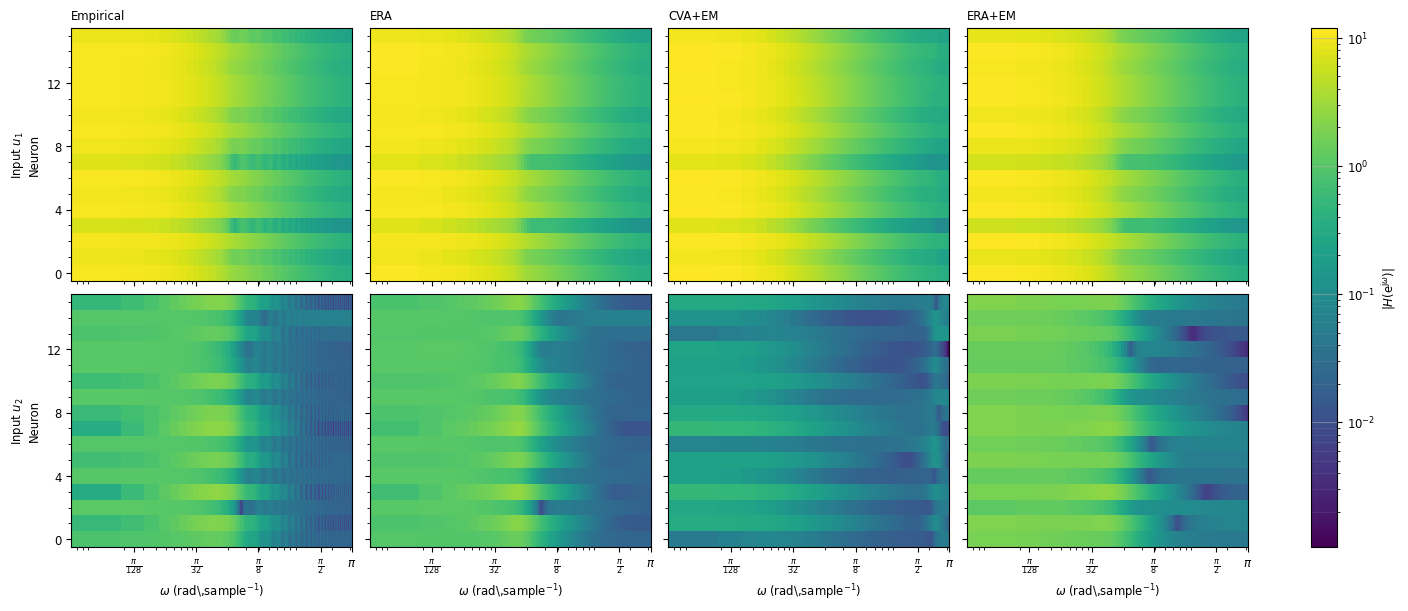

In [5]:
# ── figure: display ──────────────────────────────────────────────────────────
configure_screen()
fig = make_freq_map_figure(freqs, H_emp, model_responses, figsize=(14, 6))
apply_figure_style(fig)
plt.show()

In [6]:
# ── pgf export ───────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.24  # fraction of A4 content height

configure_pgf()
fig = make_freq_map_figure(
    freqs, H_emp, model_responses,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "freq_map.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/freq_map.pgf


In [7]:
# ── caption ─────────────────────────────────────────────────────────────────
q = ESTIMATES[0].C.shape[0]
model_names = ", ".join(
    (est.label if i < len(ESTIMATES) - 1 else f"and {est.label}")
    for i, est in enumerate(ESTIMATES)
)

caption = (
    r"Per-neuron frequency selectivity for inputs $u_1$ (top row) and $u_2$"
    r" (bottom row). Each panel shows"
    r" $|H(\mathrm{e}^{\mathrm{j}\omega})|$"
    r" for all $n_y = "
    + str(q)
    + r"$ neurons (vertical axis) across $\omega \in [0, \pi]$"
    r" rad\,sample$^{-1}$ (horizontal axis), on a shared logarithmic"
    r" colour scale. Leftmost column shows the empirical response"
    r" (DFT of "
    + str(N_MARKOV)
    + r" Markov parameters, zero-padded to "
    + str(N_FFT)
    + r" points); remaining columns show the analytic transfer function"
    r" $H(\mathrm{e}^{\mathrm{j}\omega}) ="
    r" C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$"
    r" for "
    + model_names
    + r" respectively."
)
save_caption(CAPTIONS_PATH / "freq_map.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/freq_map.tex
Per-neuron frequency selectivity for inputs $u_1$ (top row) and $u_2$ (bottom row). Each panel shows $|H(\mathrm{e}^{\mathrm{j}\omega})|$ for all $n_y = 16$ neurons (vertical axis) across $\omega \in [0, \pi]$ rad\,sample$^{-1}$ (horizontal axis), on a shared logarithmic colour scale. Leftmost column shows the empirical response (DFT of 55 Markov parameters, zero-padded to 512 points); remaining columns show the analytic transfer function $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$ for ERA, CVA+EM, and ERA+EM respectively.
